In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
wine = load_wine()

X = wine.data
y = wine.target

print("Dataset Shape:", X.shape)
print("Classes:", wine.target_names)

Dataset Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']


In [ ]:
df = pd.DataFrame(X, columns=wine.feature_names)
df["Target"] = y

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Targe

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 142
Testing Samples: 36


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeature scaling completed.")


Feature scaling completed.


In [ ]:
def create_model(regularizer=None):

    model = Sequential()

    # Input Layer + First Hidden Layer
    model.add(Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizer,
        input_shape=(13,)
    ))

    # Second Hidden Layer
    model.add(Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizer
    ))

    # Output Layer
    model.add(Dense(
        3,
        activation="softmax"
    ))

    # Compile Model
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
basic_model = create_model()

print("\nBasic MLP Architecture:")
basic_model.summary()

history_basic = basic_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

pred_basic = np.argmax(
    basic_model.predict(X_test, verbose=0),
    axis=1
)

acc_basic = accuracy_score(
    y_test,
    pred_basic
)

print("\nBasic MLP Accuracy:",
      round(acc_basic * 100, 2), "%")


Basic MLP Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)


Basic MLP Accuracy: 94.44 %


In [ ]:
l1_model = create_model(
    l1(0.001)
)

history_l1 = l1_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

pred_l1 = np.argmax(
    l1_model.predict(X_test, verbose=0),
    axis=1
)

acc_l1 = accuracy_score(
    y_test,
    pred_l1
)

print("L1 Regularization Accuracy:",
      round(acc_l1 * 100, 2), "%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


L1 Regularization Accuracy: 97.22 %


In [ ]:
l2_model = create_model(
    l2(0.001)
)

history_l2 = l2_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

pred_l2 = np.argmax(
    l2_model.predict(X_test, verbose=0),
    axis=1
)

acc_l2 = accuracy_score(
    y_test,
    pred_l2
)

print("L2 Regularization Accuracy:",
      round(acc_l2 * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


L2 Regularization Accuracy: 97.22 %


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

early_model = create_model()

history_early = early_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

pred_early = np.argmax(
    early_model.predict(X_test, verbose=0),
    axis=1
)

acc_early = accuracy_score(
    y_test,
    pred_early
)

print("Early Stopping Accuracy:",
      round(acc_early * 100, 2), "%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Early Stopping Accuracy: 97.22 %



Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


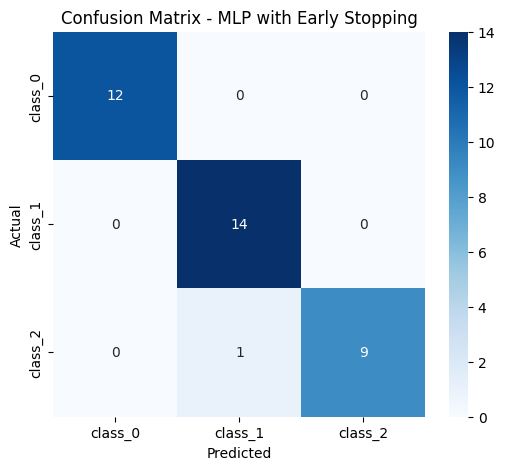

In [ ]:
cm = confusion_matrix(
    y_test,
    pred_early
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP with Early Stopping")

plt.show()

In [ ]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        pred_early,
        target_names=wine.target_names
    )
)


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [ ]:
results = pd.DataFrame({
    "Model": [
        "Basic MLP",
        "MLP + L1",
        "MLP + L2",
        "MLP + Early Stopping"
    ],
    "Accuracy": [
        acc_basic,
        acc_l1,
        acc_l2,
        acc_early
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

print("\nAccuracy Comparison:")
print(results[["Model", "Accuracy (%)"]])


Accuracy Comparison:
                  Model  Accuracy (%)
0             Basic MLP     94.444444
1              MLP + L1     97.222222
2              MLP + L2     97.222222
3  MLP + Early Stopping     97.222222


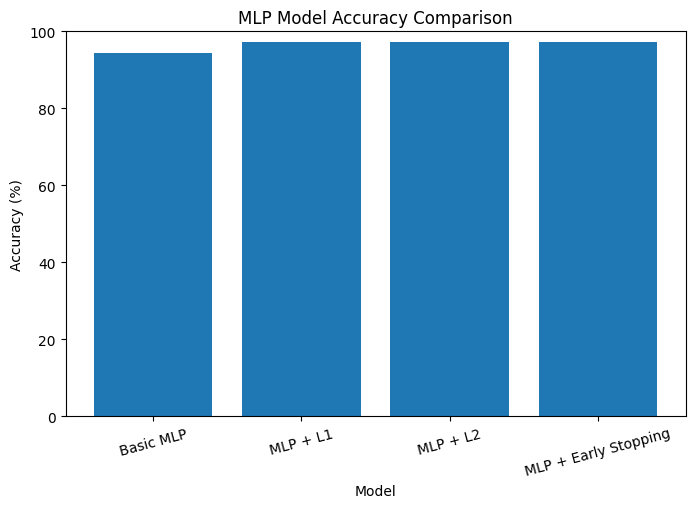

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("MLP Model Accuracy Comparison")

plt.xticks(rotation=15)
plt.ylim(0, 100)

plt.show()